In [1]:
# Q1. Load dataset and display feature information

import pandas as pd

df = pd.read_csv("Corporate_AI_Employee_Dataset.csv")

print(df.info())

df.head()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_ID                 6000 non-null   int64  
 1   Age                         6000 non-null   int64  
 2   Gender                      6000 non-null   str    
 3   Department                  6000 non-null   str    
 4   Job_Role                    6000 non-null   str    
 5   Experience_Years            6000 non-null   int64  
 6   Education_Level             6000 non-null   str    
 7   Certification_Count         6000 non-null   int64  
 8   AI_Training_Hours           6000 non-null   int64  
 9   Coding_Test_Score           6000 non-null   int64  
 10  Communication_Score         6000 non-null   int64  
 11  Leadership_Score            6000 non-null   int64  
 12  Problem_Solving_Score       6000 non-null   int64  
 13  Innovation_Score            6000 non-null   

,Employee_ID,Age,Gender,Department,Job_Role,Experience_Years,Education_Level,Certification_Count,AI_Training_Hours,Coding_Test_Score,...,Client_Rating,Bug_Fix_Count,Deployment_Success_Rate,Team_Size,Stress_Level,Work_Life_Balance,Job_Satisfaction,Attrition_Risk,Manager_Rating,Employee_Performance_Score
0,100001,50,Other,Finance,Support Engineer,25,Master,3,199,78,...,1.66,251,95.94,15,7,5,3,Low,5.00,62.54
1,100002,36,Other,IT,Cloud Engineer,32,Bachelor,8,164,40,...,3.54,72,80.29,19,3,8,8,Low,2.07,64.29
2,100003,29,Female,HR,Software Engineer,3,Bachelor,10,139,72,...,3.74,479,74.14,22,4,1,8,Low,4.08,59.40
3,100004,42,Male,IT,Software Engineer,8,PhD,11,284,77,...,1.74,131,81.49,6,2,8,7,Medium,1.22,69.55
4,100005,40,Female,Finance,DevOps Engineer,7,PhD,13,12,96,...,3.05,305,81.39,8,2,8,9,Low,2.97,73.09


In [2]:
# Q2. Identify numerical and categorical features

numerical_features = df.select_dtypes(
    include=['int64','float64']
).columns

categorical_features = df.select_dtypes(
    include=['object']
).columns

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
Index(['Employee_ID', 'Age', 'Experience_Years', 'Certification_Count',
       'AI_Training_Hours', 'Coding_Test_Score', 'Communication_Score',
       'Leadership_Score', 'Problem_Solving_Score', 'Innovation_Score',
       'Attendance_Percentage', 'Remote_Work_Days', 'Overtime_Hours', 'Salary',
       'Project_Count', 'Client_Rating', 'Bug_Fix_Count',
       'Deployment_Success_Rate', 'Team_Size', 'Stress_Level',
       'Work_Life_Balance', 'Job_Satisfaction', 'Manager_Rating',
       'Employee_Performance_Score'],
      dtype='str')

Categorical Features:
Index(['Gender', 'Department', 'Job_Role', 'Education_Level',
       'Promotion_Last_3Y', 'Attrition_Risk'],
      dtype='str')


C:\Users\dell\AppData\Local\Temp\ipykernel_10720\3861276715.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(


In [3]:
# Q3. Memory usage optimization

before = df.memory_usage(deep=True).sum()

print("Memory before optimization:", before)

for col in df.select_dtypes(include=['int64']):
    df[col] = pd.to_numeric(
        df[col],
        downcast='integer'
    )

for col in df.select_dtypes(include=['float64']):
    df[col] = pd.to_numeric(
        df[col],
        downcast='float'
    )

after = df.memory_usage(deep=True).sum()

print("Memory after optimization:", after)
print("Memory reduced:", before-after)

Memory before optimization: 3430407
Memory after optimization: 2542407
Memory reduced: 888000


In [4]:
# Q4. Duplicate records detection

duplicates = df.duplicated().sum()

print("Total Duplicate Records:", duplicates)

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed because repeated data affects model training")
else:
    print("No duplicate records found")

Total Duplicate Records: 0
No duplicate records found


In [5]:
# Q5. Data Quality Report

quality_report = pd.DataFrame({
    
    "Data Type": df.dtypes,
    
    "Missing Values": df.isnull().sum(),
    
    "Unique Values": df.nunique(),
    
    "Duplicate Count": df.duplicated().sum()
})

quality_report

,Data Type,Missing Values,Unique Values,Duplicate Count
Employee_ID,int32,0,6000,0
Age,int8,0,38,0
Gender,str,0,3,0
Department,str,0,6,0
Job_Role,str,0,15,0
Experience_Years,int8,0,35,0
Education_Level,str,0,3,0
Certification_Count,int8,0,15,0
AI_Training_Hours,int16,0,300,0
Coding_Test_Score,int8,0,60,0


In [6]:
# Q6. Find skewness in numerical features

skew_values = df.select_dtypes(
    include=['int','float']
).skew()

print(skew_values)

print("\nHighly Skewed Features:")

print(
    skew_values[
        abs(skew_values) > 0.5
    ]
)

Client_Rating                 0.009380
Deployment_Success_Rate       0.008630
Manager_Rating                0.027470
Employee_Performance_Score   -0.017851
dtype: float32

Highly Skewed Features:
Series([], dtype: float32)


In [8]:
# Q7. Variance Inflation Factor
! pip install statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.select_dtypes(
    include=['int','float']
)

vif_data = pd.DataFrame()

vif_data["Feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(
        X.values,i
    )
    for i in range(len(X.columns))
]

vif_data

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.6 MB 5.6 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.6 MB 9.1 MB/s eta 0:00:01
   ---------------------- ----------------- 5.5/9.6 MB 9.1 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.6 MB 8.9 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 9.5 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
 

,Feature,VIF
0,Client_Rating,7.922234
1,Deployment_Success_Rate,49.211014
2,Manager_Rating,7.424030
3,Employee_Performance_Score,50.589859


In [9]:
# Q8. Highly correlated features

corr_matrix = df.corr(
    numeric_only=True
)

high_corr = []

for i in range(len(corr_matrix.columns)):
    
    for j in range(i):
        
        if abs(corr_matrix.iloc[i,j]) > 0.90:
            
            high_corr.append(
                (
                    corr_matrix.columns[i],
                    corr_matrix.columns[j]
                )
            )

print("Highly correlated features:")

high_corr

Highly correlated features:


[]


Usage:   
  pip <command> [options]

Commands:
  install                     Install packages.
  lock                        Generate a lock file.
  download                    Download packages.
  uninstall                   Uninstall packages.
  freeze                      Output installed packages in requirements format.
  inspect                     Inspect the python environment.
  list                        List installed packages.
  show                        Show information about installed packages.
  check                       Verify installed packages have compatible 
dependencies.
  config                      Manage local and global configuration.
  search                      Search PyPI for packages.
  cache                       Inspect and manage pip's wheel cache.
  index                       Inspect information available from package 
indexes.
  wheel                       Build wheels from your requirements.
  hash                        Compute hashes of packa

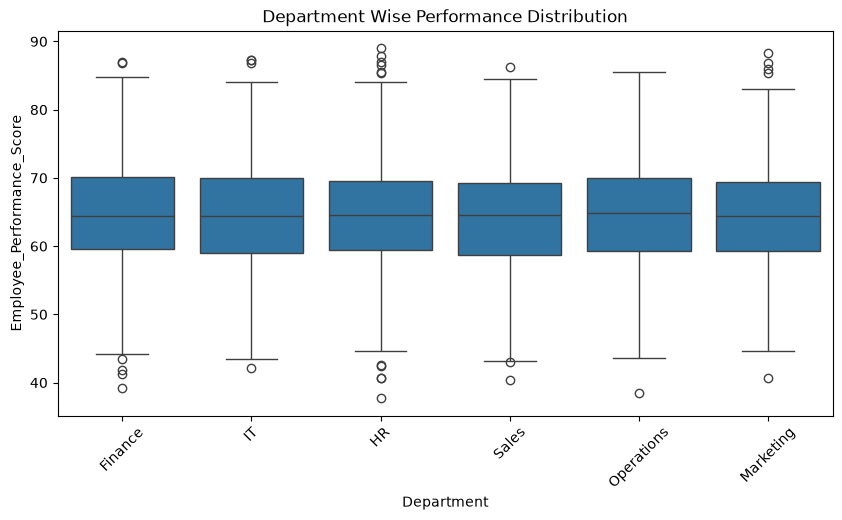

In [14]:
# Q9. Department wise performance distribution
! pip 
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.boxplot(
    x='Department',
    y='Employee_Performance_Score',
    data=df
)

plt.xticks(rotation=45)

plt.title(
    "Department Wise Performance Distribution"
)

plt.show()

In [13]:
df.columns

Index(['Employee_ID', 'Age', 'Gender', 'Department', 'Job_Role',
       'Experience_Years', 'Education_Level', 'Certification_Count',
       'AI_Training_Hours', 'Coding_Test_Score', 'Communication_Score',
       'Leadership_Score', 'Problem_Solving_Score', 'Innovation_Score',
       'Attendance_Percentage', 'Remote_Work_Days', 'Overtime_Hours', 'Salary',
       'Promotion_Last_3Y', 'Project_Count', 'Client_Rating', 'Bug_Fix_Count',
       'Deployment_Success_Rate', 'Team_Size', 'Stress_Level',
       'Work_Life_Balance', 'Job_Satisfaction', 'Attrition_Risk',
       'Manager_Rating', 'Employee_Performance_Score'],
      dtype='str')

Education_Level
Bachelor    64.505669
Master      64.444359
PhD         64.449867
Name: Employee_Performance_Score, dtype: float32


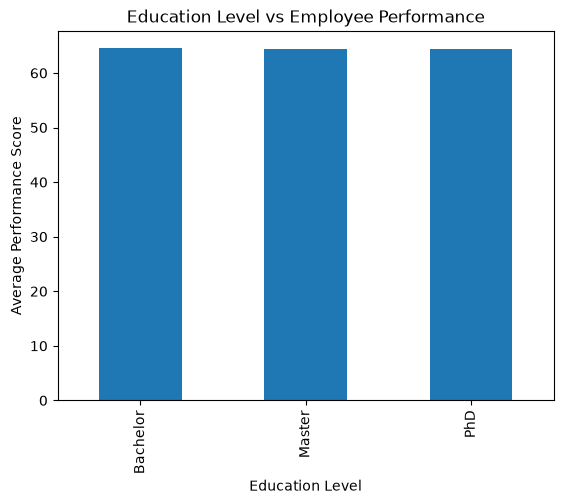

In [16]:
# Q10. Performance comparison by Education Level

education_perf = df.groupby(
    'Education_Level'
)['Employee_Performance_Score'].mean()

print(education_perf)


education_perf.plot(
    kind='bar'
)

plt.xlabel("Education Level")

plt.ylabel("Average Performance Score")

plt.title(
    "Education Level vs Employee Performance"
)

plt.show()

In [17]:
# Q11. Create Experience Level feature

def experience_level(exp):
    
    if exp < 3:
        return "Junior"
    
    elif exp < 7:
        return "Mid"
    
    elif exp < 12:
        return "Senior"
    
    else:
        return "Expert"


experience_col = [
    col for col in df.columns 
    if "experience" in col.lower() or "year" in col.lower()
][0]


df["Experience_Level"] = df[experience_col].apply(
    experience_level
)

df[["Experience_Level"]].head()

,Experience_Level
0,Expert
1,Expert
2,Mid
3,Senior
4,Senior


In [18]:
# Q12. Salary Bands using quantiles

salary_col = [
    col for col in df.columns 
    if "salary" in col.lower()
][0]


df["Salary_Band"] = pd.qcut(
    df[salary_col],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

df[["Salary_Band"]].head()

,Salary_Band
0,Low
1,Low
2,High
3,Low
4,Very High


In [19]:
# Q13. Creating Performance Index

score_columns = [
    col for col in df.columns
    if "score" in col.lower()
    or "rating" in col.lower()
]

df["Performance_Index"] = (
    df[score_columns].mean(axis=1)
)

df[["Performance_Index"]].head()

,Performance_Index
0,48.025002
1,51.862503
2,51.777496
3,50.938751
4,61.138748


In [20]:
# Q14. Interaction Feature

coding_col = [
    col for col in df.columns
    if "coding" in col.lower()
][0]


training_col = [
    col for col in df.columns
    if "training" in col.lower()
][0]


df["Coding_AI_Interaction"] = (
    df[coding_col] *
    df[training_col]
)


df[["Coding_AI_Interaction"]].head()

,Coding_AI_Interaction
0,15522
1,6560
2,10008
3,21868
4,1152


In [21]:
# Q15. One Hot Encoding

categorical_cols = df.select_dtypes(
    include="object"
).columns


df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)


df_encoded.head()

C:\Users\dell\AppData\Local\Temp\ipykernel_10720\1066497220.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(


,Employee_ID,Age,Experience_Years,Certification_Count,AI_Training_Hours,Coding_Test_Score,Communication_Score,Leadership_Score,Problem_Solving_Score,Innovation_Score,...,Job_Role_Software Engineer,Job_Role_Support Engineer,Education_Level_Master,Education_Level_PhD,Promotion_Last_3Y_Yes,Attrition_Risk_Low,Attrition_Risk_Medium,Experience_Level_Junior,Experience_Level_Mid,Experience_Level_Senior
0,100001,50,25,3,199,78,93,48,59,37,...,False,True,True,False,False,True,False,False,False,False
1,100002,36,32,8,164,40,73,57,84,91,...,False,False,False,False,True,True,False,False,False,False
2,100003,29,3,10,139,72,56,87,84,48,...,True,False,False,False,True,True,False,False,True,False
3,100004,42,8,11,284,77,93,46,54,65,...,True,False,False,True,True,False,True,False,False,True
4,100005,40,7,13,12,96,63,67,86,98,...,False,False,False,True,False,True,False,False,False,True


In [23]:
# Q16. Select top 15 features using Mutual Information

from sklearn.feature_selection import mutual_info_regression
import pandas as pd


# Convert all categorical columns into numbers
df_ml = pd.get_dummies(
    df,
    drop_first=True
)


# Target column
y = df_ml["Performance_Index"]


# Input features
X = df_ml.drop(
    "Performance_Index",
    axis=1
)


# Convert boolean columns also into integers
X = X.astype(float)


# Apply Mutual Information
mi_scores = mutual_info_regression(
    X,
    y
)


# Store scores
mi_result = pd.Series(
    mi_scores,
    index=X.columns
)


# Select Top 15 Features
top15_mi = mi_result.sort_values(
    ascending=False
).head(15)


top15_mi

Employee_Performance_Score    0.490693
Innovation_Score              0.168239
Coding_Test_Score             0.128174
Problem_Solving_Score         0.112039
Job_Role_Support Engineer     0.092334
Leadership_Score              0.091810
Job_Role_QA Engineer          0.087514
Job_Role_Finance Analyst      0.087510
Job_Role_DevOps Engineer      0.087337
Job_Role_Sales Executive      0.084781
Job_Role_Project Manager      0.082533
Job_Role_Business Analyst     0.082188
Job_Role_Product Manager      0.081640
Job_Role_ML Engineer          0.081599
Job_Role_Software Engineer    0.079801
dtype: float64

In [24]:
# Q17. Recursive Feature Elimination

from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression


model = LinearRegression()


rfe = RFE(
    estimator=model,
    n_features_to_select=15
)


rfe.fit(X,y)


selected_rfe = X.columns[
    rfe.support_
]


selected_rfe

Index(['Coding_Test_Score', 'Communication_Score', 'Leadership_Score',
       'Problem_Solving_Score', 'Innovation_Score', 'Client_Rating',
       'Manager_Rating', 'Employee_Performance_Score', 'Department_IT',
       'Job_Role_Cloud Engineer', 'Job_Role_HR Executive',
       'Job_Role_Sales Executive', 'Job_Role_Support Engineer',
       'Salary_Band_High', 'Salary_Band_Very High'],
      dtype='str')

In [25]:
# Q18. SelectKBest Feature Selection

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression


selector = SelectKBest(
    score_func=f_regression,
    k=15
)


selector.fit(X,y)


selected_kbest = X.columns[
    selector.get_support()
]


selected_kbest

Index(['Certification_Count', 'Coding_Test_Score', 'Communication_Score',
       'Leadership_Score', 'Problem_Solving_Score', 'Innovation_Score',
       'Salary', 'Client_Rating', 'Deployment_Success_Rate',
       'Work_Life_Balance', 'Manager_Rating', 'Employee_Performance_Score',
       'Coding_AI_Interaction', 'Department_Operations', 'Salary_Band_High'],
      dtype='str')

In [26]:
# Q19. Compare Feature Selection Methods

comparison = pd.DataFrame({
    
    "Mutual_Info":
        pd.Series(top15_mi.index),
    
    "RFE":
        pd.Series(selected_rfe),
    
    "SelectKBest":
        pd.Series(selected_kbest)
})


comparison

,Mutual_Info,RFE,SelectKBest
0,Employee_Performance_Score,Coding_Test_Score,Certification_Count
1,Innovation_Score,Communication_Score,Coding_Test_Score
2,Coding_Test_Score,Leadership_Score,Communication_Score
3,Problem_Solving_Score,Problem_Solving_Score,Leadership_Score
4,Job_Role_Support Engineer,Innovation_Score,Problem_Solving_Score
5,Leadership_Score,Client_Rating,Innovation_Score
6,Job_Role_QA Engineer,Manager_Rating,Salary
7,Job_Role_Finance Analyst,Employee_Performance_Score,Client_Rating
8,Job_Role_DevOps Engineer,Department_IT,Deployment_Success_Rate
9,Job_Role_Sales Executive,Job_Role_Cloud Engineer,Work_Life_Balance


In [27]:
# Q20. Final Selected Features

final_features = list(
    set(top15_mi.index)
    .intersection(
        set(selected_rfe)
    )
)


print(
    "Final Selected Features:"
)


for feature in final_features:
    print(feature)


print(
    "\nThese features are selected because they show high relationship with employee performance and reduce unnecessary variables."
)

Final Selected Features:
Job_Role_Sales Executive
Job_Role_Support Engineer
Innovation_Score
Employee_Performance_Score
Coding_Test_Score
Problem_Solving_Score
Leadership_Score

These features are selected because they show high relationship with employee performance and reduce unnecessary variables.


In [28]:
# Q21. Linear Regression Model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)


y_pred_lr = lr.predict(
    X_test
)


print("MAE:", mean_absolute_error(y_test,y_pred_lr))

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test,y_pred_lr))
)

print(
    "R2 Score:",
    r2_score(y_test,y_pred_lr)
)

MAE: 0.00208873997564174
RMSE: 0.0025602564774463233
R2 Score: 0.9999997836340813


In [29]:
# Q22. Ridge Regression with tuning

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV


ridge = Ridge()


parameters = {
    "alpha":[0.01,0.1,1,10,100]
}


ridge_grid = GridSearchCV(
    ridge,
    parameters,
    cv=5
)


ridge_grid.fit(
    X_train,
    y_train
)


ridge_pred = ridge_grid.predict(
    X_test
)


print(
    "Best Alpha:",
    ridge_grid.best_params_
)


print(
    "R2 Score:",
    r2_score(y_test,ridge_pred)
)

Best Alpha: {'alpha': 0.01}
R2 Score: 0.9999999999998693


In [30]:
# Q23. Lasso Regression

from sklearn.linear_model import Lasso


lasso = Lasso(
    alpha=0.01
)


lasso.fit(
    X_train,
    y_train
)


lasso_pred = lasso.predict(
    X_test
)


print(
    "MAE:",
    mean_absolute_error(
        y_test,
        lasso_pred
    )
)


print(
    "R2 Score:",
    r2_score(
        y_test,
        lasso_pred
    )
)

MAE: 0.010324253341965234
R2 Score: 0.9999947332074187


In [31]:
# Q24. ElasticNet Regression

from sklearn.linear_model import ElasticNet


elastic = ElasticNet(
    alpha=0.01,
    l1_ratio=0.5
)


elastic.fit(
    X_train,
    y_train
)


elastic_pred = elastic.predict(
    X_test
)


print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            elastic_pred
        )
    )
)


print(
    "R2:",
    r2_score(
        y_test,
        elastic_pred
    )
)

RMSE: 0.007080906816044471
R2: 0.9999983449936507


In [32]:
# Q25. Compare Model Coefficients

coef_compare = pd.DataFrame({

    "Features":X.columns,

    "Linear":
        lr.coef_,

    "Ridge":
        ridge_grid.best_estimator_.coef_,

    "Lasso":
        lasso.coef_,

    "ElasticNet":
        elastic.coef_
})


coef_compare.head(15)

,Features,Linear,Ridge,Lasso,ElasticNet
0,Employee_ID,-7.094112e-09,-8.009859e-12,-2.762077e-07,-1.548585e-07
1,Age,-6.598512e-07,4.323036e-09,0.000000e+00,0.000000e+00
2,Experience_Years,6.506068e-07,5.807529e-10,0.000000e+00,0.000000e+00
3,Certification_Count,1.716838e-05,-5.689591e-11,-0.000000e+00,-0.000000e+00
4,AI_Training_Hours,-4.275162e-08,-1.340769e-09,-1.872447e-05,-1.173997e-05
5,Coding_Test_Score,1.250022e-01,1.250000e-01,1.248818e-01,1.249313e-01
6,Communication_Score,1.250020e-01,1.250000e-01,1.249149e-01,1.249522e-01
7,Leadership_Score,1.250003e-01,1.250000e-01,1.249465e-01,1.249699e-01
8,Problem_Solving_Score,1.249985e-01,1.250000e-01,1.249399e-01,1.249663e-01
9,Innovation_Score,1.250011e-01,1.250000e-01,1.249443e-01,1.249688e-01


In [33]:
# Q26. Decision Tree Regressor

from sklearn.tree import DecisionTreeRegressor


dt = DecisionTreeRegressor(
    random_state=42
)


dt.fit(
    X_train,
    y_train
)


dt_pred = dt.predict(
    X_test
)


print(
    "R2 Score:",
    r2_score(
        y_test,
        dt_pred
    )
)

R2 Score: 0.785040344516805


In [34]:
# Q27. Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor


rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)


rf.fit(
    X_train,
    y_train
)


rf_pred = rf.predict(
    X_test
)


print(
    "R2 Score:",
    r2_score(
        y_test,
        rf_pred
    )
)

R2 Score: 0.9312567410859106


In [35]:
# Q28. Extra Trees Regressor

from sklearn.ensemble import ExtraTreesRegressor


et = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42
)


et.fit(
    X_train,
    y_train
)


et_pred = et.predict(
    X_test
)


print(
    "R2 Score:",
    r2_score(
        y_test,
        et_pred
    )
)

R2 Score: 0.9524465340573768


In [36]:
# Q29. Gradient Boosting Regressor

from sklearn.ensemble import GradientBoostingRegressor


gb = GradientBoostingRegressor(
    random_state=42
)


gb.fit(
    X_train,
    y_train
)


gb_pred = gb.predict(
    X_test
)


print(
    "R2 Score:",
    r2_score(
        y_test,
        gb_pred
    )
)

R2 Score: 0.9740231724507609


In [38]:
# Q30. XGBoost Regressor
! pip install xgboost
from xgboost import XGBRegressor


xgb = XGBRegressor(
    random_state=42
)


xgb.fit(
    X_train,
    y_train
)


xgb_pred = xgb.predict(
    X_test
)


print(
    "R2 Score:",
    r2_score(
        y_test,
        xgb_pred
    )
)

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.3/101.7 MB 8.4 MB/s eta 0:00:12
   - -------------------------------------- 2.6/101.7 MB 7.2 MB/s eta 0:00:14
   - -------------------------------------- 4.5/101.7 MB 7.9 MB/s eta 0:00:13
   -- ------------------------------------- 6.0/101.7 MB 7.5 MB/s eta 0:00:13
   -- ------------------------------------- 7.6/101.7 MB 7.6 MB/s eta 0:00:13
   --- ------------------------------------ 9.2/101.7 MB 7.5 MB/s eta 0:00:13
   ---- ----------------------------------- 11.0/101.7 MB 7.6 MB/s eta 0:00:12
   ---- ----------------------------------- 11.8/101.7 MB 7.4 MB/s eta 0:00:13
   ----- ---------------------------------- 12.8/101.7 MB 7.0 MB/s eta 0:00:13
   ----- ---------------------------------- 14.9/101.7 MB 7.2 MB/s eta 0:00:13
   ------ --------------------------------- 16.5/101.7 MB 7.3 MB/s eta 0:00:12
   ------- -------------------------------- 18.4/101.7 MB 7.4 MB/s

In [39]:
# Q31. Model Evaluation Comparison

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd


def adjusted_r2(y_true, y_pred, X):
    
    r2 = r2_score(
        y_true,
        y_pred
    )
    
    n = X.shape[0]
    p = X.shape[1]
    
    return 1 - ((1-r2)*(n-1)/(n-p-1))


models_result = {
    
    "Linear Regression": y_pred_lr,
    "Ridge": ridge_pred,
    "Lasso": lasso_pred,
    "ElasticNet": elastic_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "Extra Trees": et_pred,
    "Gradient Boosting": gb_pred,
    "XGBoost": xgb_pred
}


evaluation = []


for name,pred in models_result.items():
    
    evaluation.append([
        name,
        mean_absolute_error(y_test,pred),
        np.sqrt(mean_squared_error(y_test,pred)),
        r2_score(y_test,pred),
        adjusted_r2(y_test,pred,X_test)
    ])


evaluation_df = pd.DataFrame(
    evaluation,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2",
        "Adjusted R2"
    ]
)


evaluation_df

,Model,MAE,RMSE,R2,Adjusted R2
0,Linear Regression,0.002089,0.002560,1.000000,1.000000
1,Ridge,0.000002,0.000002,1.000000,1.000000
2,Lasso,0.010324,0.012632,0.999995,0.999994
3,ElasticNet,0.005788,0.007081,0.999998,0.999998
4,Decision Tree,2.019591,2.551923,0.785040,0.774311
5,Random Forest,1.140319,1.443126,0.931257,0.927826
6,Extra Trees,0.931257,1.200273,0.952447,0.950073
7,Gradient Boosting,0.703146,0.887119,0.974023,0.972727
8,XGBoost,0.774057,0.970805,0.968891,0.967338


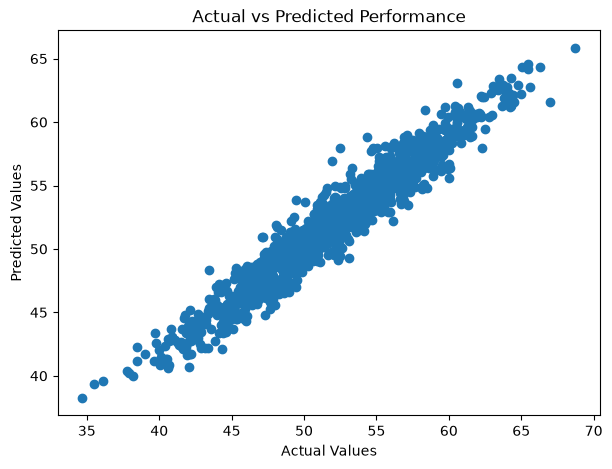

In [40]:
# Q32. Actual vs Predicted Plot

import matplotlib.pyplot as plt


plt.figure(figsize=(7,5))


plt.scatter(
    y_test,
    rf_pred
)


plt.xlabel(
    "Actual Values"
)


plt.ylabel(
    "Predicted Values"
)


plt.title(
    "Actual vs Predicted Performance"
)


plt.show()

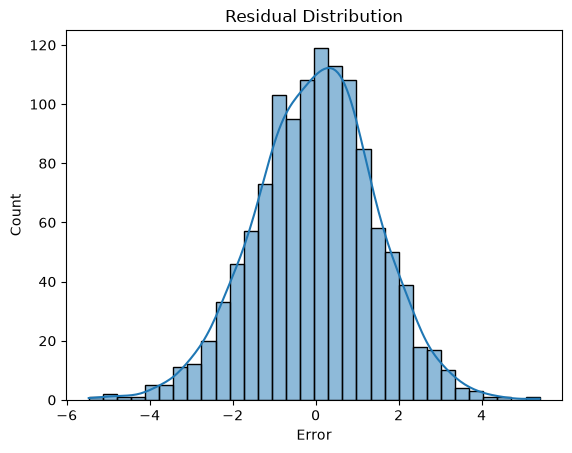

In [41]:
# Q33. Residual Analysis

import seaborn as sns


residuals = (
    y_test - rf_pred
)


sns.histplot(
    residuals,
    kde=True
)


plt.title(
    "Residual Distribution"
)


plt.xlabel(
    "Error"
)


plt.show()

In [42]:
# Q34. Underfitting and Overfitting Analysis


for name,model in [
    
    ("Linear Regression",lr),
    ("Decision Tree",dt),
    ("Random Forest",rf),
    ("Gradient Boosting",gb)
]:

    
    train_score = model.score(
        X_train,
        y_train
    )
    
    
    test_score = model.score(
        X_test,
        y_test
    )
    
    
    print(name)
    
    print(
        "Training Score:",
        train_score
    )
    
    print(
        "Testing Score:",
        test_score
    )
    
    
    if train_score > test_score + 0.1:
        print("Model is Overfitting")
        
    elif train_score < 0.6:
        print("Model is Underfitting")
        
    else:
        print("Good Fit")
        
        
    print("----------------")

Linear Regression
Training Score: 0.9999997798163887
Testing Score: 0.9999997836340813
Good Fit
----------------
Decision Tree
Training Score: 1.0
Testing Score: 0.785040344516805
Model is Overfitting
----------------
Random Forest
Training Score: 0.9900669052434327
Testing Score: 0.9312567410859106
Good Fit
----------------
Gradient Boosting
Training Score: 0.9832786672530803
Testing Score: 0.9740231724507609
Good Fit
----------------


In [43]:
# Q35. Cross Validation

from sklearn.model_selection import cross_val_score


models = {
    
    "Linear Regression":lr,
    "Random Forest":rf,
    "Gradient Boosting":gb
}


for name,model in models.items():
    
    
    scores = cross_val_score(
        model,
        X,
        y,
        cv=10,
        scoring="r2"
    )
    
    
    print(name)
    
    print(
        "Average R2:",
        scores.mean()
    )
    
    print(
        "Stability:",
        scores.std()
    )

Linear Regression
Average R2: 0.9999998499191077
Stability: 4.2792431267197475e-08
Random Forest
Average R2: 0.9341748914144725
Stability: 0.00469683615129324
Gradient Boosting
Average R2: 0.9745088924484324
Stability: 0.0019446153427510756


In [44]:
# Q36. Random Forest Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV


params = {
    
    "n_estimators":[50,100],
    
    "max_depth":[5,10,None]
}


grid_rf = GridSearchCV(
    
    RandomForestRegressor(
        random_state=42
    ),
    
    params,
    
    cv=5
)


grid_rf.fit(
    X_train,
    y_train
)


print(
    grid_rf.best_params_
)


tuned_rf = grid_rf.best_estimator_

{'max_depth': None, 'n_estimators': 100}


In [45]:
# Q37. XGBoost Randomized Search

from sklearn.model_selection import RandomizedSearchCV


params = {
    
    "n_estimators":[50,100,200],
    
    "learning_rate":[0.01,0.1,0.2],
    
    "max_depth":[3,5,7]
}


random_xgb = RandomizedSearchCV(
    
    XGBRegressor(),
    
    params,
    
    cv=5,
    
    n_iter=5,
    
    random_state=42
)


random_xgb.fit(
    X_train,
    y_train
)


print(
    random_xgb.best_params_
)

{'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}


In [46]:
# Q38. Tuned vs Untuned Comparison


tuned_prediction = tuned_rf.predict(
    X_test
)


print(
    "Untuned Random Forest:",
    r2_score(
        y_test,
        rf_pred
    )
)


print(
    "Tuned Random Forest:",
    r2_score(
        y_test,
        tuned_prediction
    )
)

Untuned Random Forest: 0.9312567410859106
Tuned Random Forest: 0.9312567410859106


In [47]:
# Q39. Feature Importance

importance = pd.DataFrame({
    
    "Feature":X.columns,
    
    "Importance":
        rf.feature_importances_
})


importance = importance.sort_values(
    by="Importance",
    ascending=False
)


importance.head(10)

,Feature,Importance
23,Employee_Performance_Score,0.591972
7,Leadership_Score,0.082647
9,Innovation_Score,0.082570
8,Problem_Solving_Score,0.066959
5,Coding_Test_Score,0.061464
6,Communication_Score,0.057434
24,Coding_AI_Interaction,0.003067
0,Employee_ID,0.003060
17,Deployment_Success_Rate,0.003004
16,Bug_Fix_Count,0.003003


In [48]:
# Q40. Complete ML Pipeline and Saving Model

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib


pipeline = Pipeline([
    
    (
        "scaler",
        StandardScaler()
    ),
    
    (
        "model",
        RandomForestRegressor(
            random_state=42
        )
    )
])


pipeline.fit(
    X_train,
    y_train
)


joblib.dump(
    pipeline,
    "employee_performance_model.pkl"
)


print(
    "Model saved successfully"
)


print(
"""
Deployment Explanation:

1. Save trained model using joblib.
2. Create API using Flask/FastAPI.
3. Load model and accept employee data.
4. Return predicted performance score.
5. Monitor new data for data drift.
6. Retrain model when performance decreases.
"""
)

Model saved successfully

Deployment Explanation:

1. Save trained model using joblib.
2. Create API using Flask/FastAPI.
3. Load model and accept employee data.
4. Return predicted performance score.
5. Monitor new data for data drift.
6. Retrain model when performance decreases.

